# 4.2 Model Analysis — SHAP Interpretation

SHAP values and feature importance for the best-performing models on the full feature set.

**Pipeline:** Gold → Interpretation  
**Input:** `Data/3_Gold/basetable_preprocessed.csv`  
**Output:** SHAP visualisations and feature importance plots

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Retrain best models (hardcoded hyperparameters)](#1-retrain-best-models-hardcoded-hyperparameters)
- [2. Feature Importance — XGBoost & Random Forest](#2-feature-importance-xgboost-random-forest)
- [3. SHAP — XGBoost TreeExplainer](#3-shap-xgboost-treeexplainer)
  - [What is a SHAP value?](#what-is-a-shap-value)
  - [Why is the expected value ≈ 0?](#why-is-the-expected-value-0)
  - [Why is TreeExplainer exact?](#why-is-treeexplainer-exact)
- [4. SHAP — SVM KernelExplainer *(overall best model)*](#4-shap-svm-kernelexplainer-overall-best-model)
  - [Why sampling?](#why-sampling)
- [5. Cross-model SHAP comparison — SVM vs XGBoost](#5-cross-model-shap-comparison-svm-vs-xgboost)
- [6. Ridge Regression — Standardised Coefficients](#6-ridge-regression-standardised-coefficients)
- [7. Predictions vs Actuals — Test Period (Oct 22 – Nov 4)](#7-predictions-vs-actuals-test-period-oct-22-nov-4)
- [8. Limitations & Honest Takeaways](#8-limitations-honest-takeaways)
  - [What the numbers actually mean](#what-the-numbers-actually-mean)
  - [The model disagreement problem (ρ = 0.041)](#the-model-disagreement-problem-ρ-0041)
  - [The test window caveat](#the-test-window-caveat)
  - [What we can trust](#what-we-can-trust)


## Setup

In [20]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import json as _json
import matplotlib.dates as mdates
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

from Functions.data_splits import get_cv_folds, get_test_split, validate_no_leakage
from Functions.evaluation_metrics import compute_metrics, directional_accuracy
from house_style import *
apply_style()

# ── Paths & constants ─────────────────────────────────────────────────────────
DATA_PATH  = '../../Data/3_Gold/basetable_preprocessed.csv'
TARGET_COL = 'polymarket_trump_prob'
LAG1_COL   = 'polymarket_trump_prob_lag1'
EXCLUDE    = {'date', TARGET_COL, LAG1_COL}

TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1
RANDOM_STATE = 42

# ── Best hyperparameters from full.ipynb ──────────────────────────────────────
SVM_PARAMS = {'kernel': 'rbf', 'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
XGB_PARAMS = {'max_depth': 2, 'learning_rate': 0.01, 'n_estimators': 100,
              'random_state': RANDOM_STATE, 'n_jobs': -1}
RF_PARAMS  = {'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200,
              'random_state': RANDOM_STATE, 'n_jobs': -1}
RIDGE_ALPHA = 1000.0

MODEL_COLORS = {
    "SVM"          : "#e85a28",
    "XGBoost"      : "#8a1a5c",
    'Random Forest': "#b39ddb",
    'Ridge'        : "#207dff",
    "SVM"          : "#e85a28"
}

print('Setup OK')

Setup OK


In [21]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

FEATURE_COLS = [c for c in df_raw.columns if c not in EXCLUDE]

df = df_raw[['date'] + FEATURE_COLS].copy()
df['target'] = df_raw[TARGET_COL] - df_raw[LAG1_COL]
df = df.dropna().reset_index(drop=True)

tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)
df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[FEATURE_COLS].values
y_tv   = df_tv['target'].values
X_test = df_test[FEATURE_COLS].values
y_test = df_test['target'].values

folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)

print(f'Features  : {len(FEATURE_COLS)}')
print(f'TV rows   : {len(df_tv)}  ({df_tv["date"].min().date()} → {df_tv["date"].max().date()})')
print(f'Test rows : {len(df_test)}  ({df_test["date"].min().date()} → {df_test["date"].max().date()})')

Features  : 111
TV rows   : 109  (2024-07-05 → 2024-10-21)
Test rows : 14  (2024-10-22 → 2024-11-04)


In [22]:
# ── Target distribution ───────────────────────────────────────────────────────
print('Target = daily change in Trump Polymarket probability')
print(f'  mean  : {y_tv.mean():+.5f}   ← near zero; this becomes the SHAP baseline')
print(f'  std   : {y_tv.std():.5f}')
print(f'  min   : {y_tv.min():+.5f}')
print(f'  max   : {y_tv.max():+.5f}')
print(f'  % positive days: {(y_tv > 0).mean():.1%}')
print(f'  % negative days: {(y_tv < 0).mean():.1%}')

Target = daily change in Trump Polymarket probability
  mean  : +0.00039   ← near zero; this becomes the SHAP baseline
  std   : 0.01732
  min   : -0.06000
  max   : +0.08000
  % positive days: 47.7%
  % negative days: 49.5%


## 1. Retrain best models (hardcoded hyperparameters)

Models are retrained on the full TV set with the tuned hyperparameters from `full.ipynb` — no re-tuning here.

**Note on metrics:**  
- **R² is negative** for all models. This is expected and *not a bug*: we are predicting near-zero daily changes that are largely noise-driven. A negative R² simply means the model does worse than predicting the mean (≈0) constantly — but our *directional accuracy* (DA) > 0.5 shows the model still captures the *sign* of movement better than chance. DA is the operationally meaningful metric here.
- **MAE ≈ 0.014–0.016** means predictions are off by about 1.4–1.6 percentage points on average, which is small relative to the ~2% election-day swings.

In [23]:
# ── Scaler (fitted on TV only — same protocol as modelling notebooks) ─────────
scaler = StandardScaler().fit(X_tv)
X_tv_s   = scaler.transform(X_tv)
X_test_s = scaler.transform(X_test)

# ── Naive baseline — always predict zero (no change) ─────────────────────────
naive_pred    = np.zeros(len(y_test))
naive_metrics = compute_metrics(y_test, naive_pred)
print('Naive (zero) :', {k: round(v, 4) for k, v in naive_metrics.items()})

# ── SVM (best overall model — DA=0.5714, MAE=0.0143) ─────────────────────────
svm = SVR(**SVM_PARAMS).fit(X_tv_s, y_tv)
svm_pred = svm.predict(X_test_s)
svm_metrics = compute_metrics(y_test, svm_pred)
print('SVM         :', {k: round(v, 4) for k, v in svm_metrics.items()})

# ── XGBoost (TreeSHAP model) ──────────────────────────────────────────────────
xgb = XGBRegressor(**XGB_PARAMS).fit(X_tv, y_tv)   # no scaling for trees
xgb_pred = xgb.predict(X_test)
xgb_metrics = compute_metrics(y_test, xgb_pred)
print('XGBoost     :', {k: round(v, 4) for k, v in xgb_metrics.items()})

# ── Random Forest (for MDI feature importance) ────────────────────────────────
rf = RandomForestRegressor(**RF_PARAMS).fit(X_tv, y_tv)
rf_pred = rf.predict(X_test)
rf_metrics = compute_metrics(y_test, rf_pred)
print('RandomForest:', {k: round(v, 4) for k, v in rf_metrics.items()})

# ── Ridge (for coefficient plot) ─────────────────────────────────────────────
ridge = Ridge(alpha=RIDGE_ALPHA).fit(X_tv_s, y_tv)
ridge_pred = ridge.predict(X_test_s)
ridge_metrics = compute_metrics(y_test, ridge_pred)
print('Ridge       :', {k: round(v, 4) for k, v in ridge_metrics.items()})

Naive (zero) : {'MAE': 0.0162, 'RMSE': np.float64(0.0208), 'Dir. Accuracy': 0.0, 'R2': -0.057}
SVM         : {'MAE': 0.0143, 'RMSE': np.float64(0.0209), 'Dir. Accuracy': 0.5714, 'R2': -0.0657}
XGBoost     : {'MAE': 0.0162, 'RMSE': np.float64(0.0215), 'Dir. Accuracy': 0.5, 'R2': -0.1291}
RandomForest: {'MAE': 0.0158, 'RMSE': np.float64(0.0215), 'Dir. Accuracy': 0.5, 'R2': -0.1343}
Ridge       : {'MAE': 0.0155, 'RMSE': np.float64(0.0208), 'Dir. Accuracy': 0.5714, 'R2': -0.0577}


## 2. Feature Importance — XGBoost & Random Forest

Tree-based feature importances as a quick baseline before computing SHAP values.

| Method | What it measures | Caveat |
|---|---|---|
| **XGBoost gain** | Average improvement in loss per split using this feature | Can be inflated by features used early in deep trees |
| **RF MDI** | Mean decrease in impurity (averaged over all trees) | Biased toward high-cardinality / continuous features |

**How to read:** Longer bar = feature used more for splits = more "useful" to the model. These metrics tell you *that* a feature matters, but **not the direction** (positive/negative effect) or magnitude per observation — that's what SHAP adds.

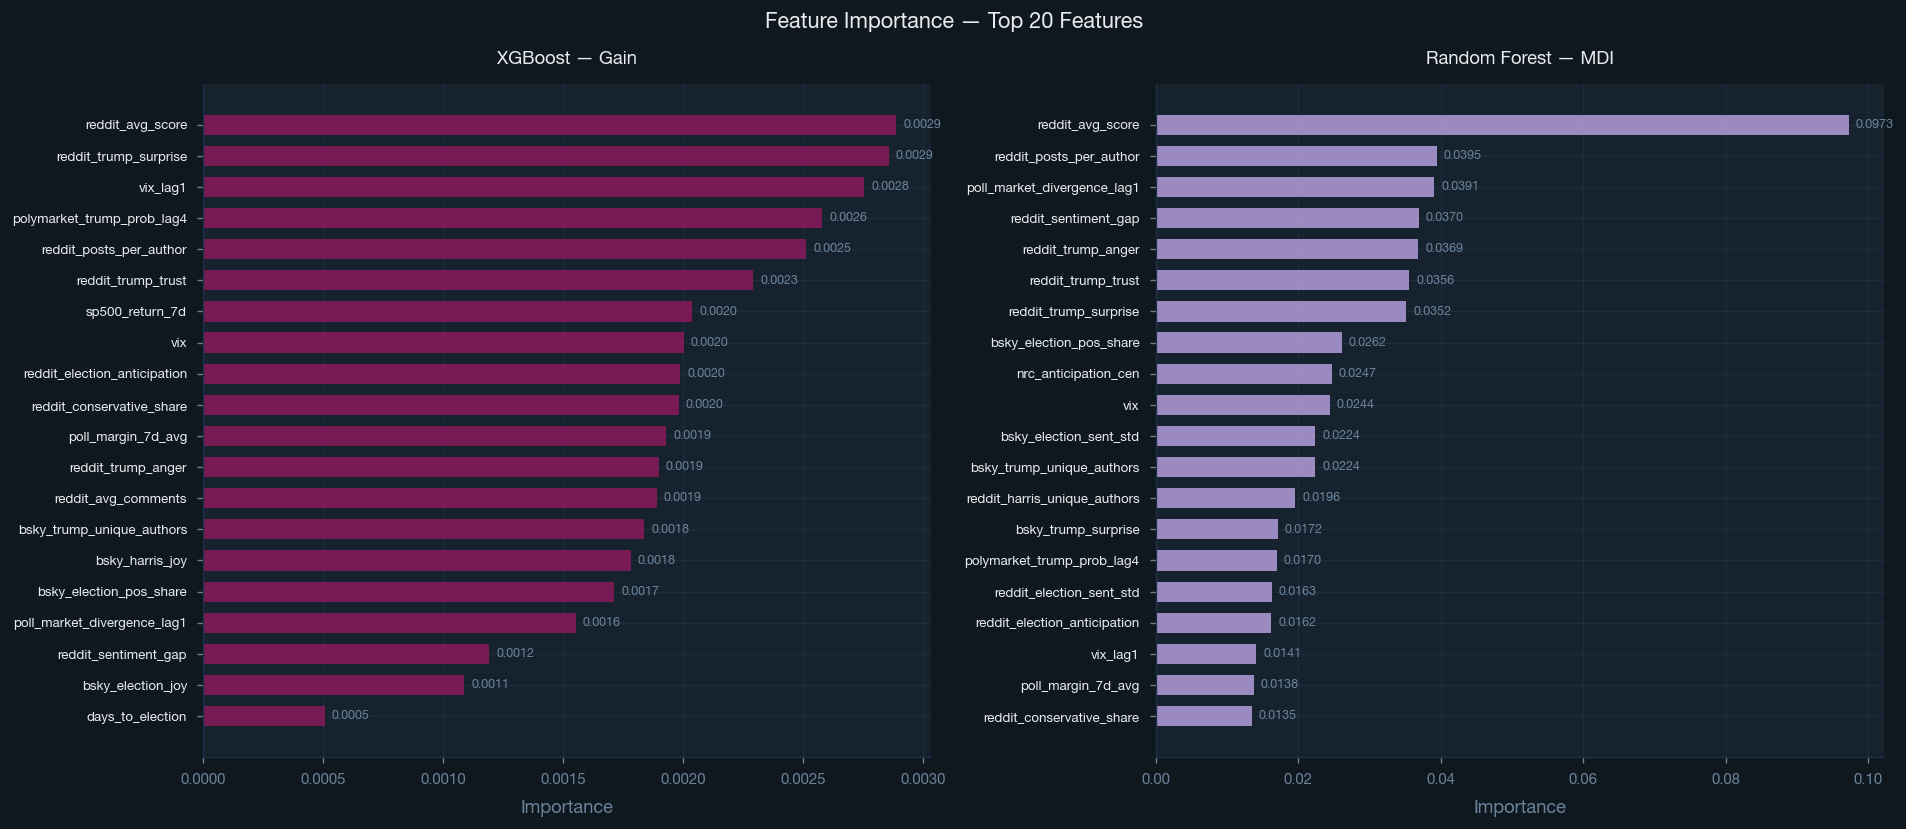

In [24]:
N_SHOW = 20

# get_score() returns keys like 'f0', 'f29', etc. (positional indices) — map back to names
raw_gain = xgb.get_booster().get_score(importance_type='gain')
named_gain = {FEATURE_COLS[int(k[1:])]: v for k, v in raw_gain.items()}
fi_xgb = pd.Series(named_gain, name='XGBoost gain').reindex(FEATURE_COLS, fill_value=0).sort_values(ascending=False)

fi_rf = pd.Series(
    rf.feature_importances_,
    index=FEATURE_COLS,
    name='RF MDI'
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(f'Feature Importance — Top {N_SHOW} Features',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')

for ax, fi, label, color in [
    (axes[0], fi_xgb, 'XGBoost — Gain',       MODEL_COLORS['XGBoost']),
    (axes[1], fi_rf,  'Random Forest — MDI',   MODEL_COLORS['Random Forest']),
]:
    ax.set_facecolor(BG_PANEL)
    top = fi.head(N_SHOW).iloc[::-1]
    bars = ax.barh(top.index, top.values, color=color, alpha=0.85, height=0.65)
    for bar, v in zip(bars, top.values):
        ax.text(bar.get_width() + top.values.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', ha='left', fontsize=7.5, color=TEXT_MUTED)
    ax.set_title(label, color=TEXT_PRIMARY, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance', color=TEXT_MUTED)
    ax.tick_params(colors=TEXT_MUTED)
    ax.set_yticklabels(top.index, color=TEXT_PRIMARY, fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.grid(axis='x', color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. SHAP — XGBoost TreeExplainer

### What is a SHAP value?
For each observation (= day) and each feature, the SHAP value φᵢ tells you:

> *"Compared to the model's average prediction, how much did feature i push today's prediction up or down?"*

- **φᵢ > 0** → feature pushed prediction *up* (model expects Trump's probability to increase more than usual)
- **φᵢ < 0** → feature pushed prediction *down*
- **Σ φᵢ = prediction − expected value** (they add up perfectly by construction)

### Why is the expected value ≈ 0?

The expected value (baseline) is the **mean of XGBoost's predictions over the training set**, which closely tracks `mean(y_tv)`. Because the target is a *daily change*, the mean daily change over 109 training days is close to zero — markets move up and down without a persistent drift. So the model's neutral stance is "predict no change," and features pull it positive or negative from there.

**This is correct behaviour, not a problem.** A baseline of ~0 means: absent any informative features, the model defaults to "no movement today."

### Why is TreeExplainer exact?

Computing true Shapley values requires evaluating every possible combination of features being present or absent — with 111 features that is 2¹¹¹ combinations, which is impossible. `TreeExplainer` sidesteps this by reading the tree structure directly: a decision tree is just a sequence of if/else splits, so it can mathematically trace exactly how much each feature contributed to each prediction by following the paths through the trees. No sampling, no approximation.

In [25]:
explainer_xgb = shap.TreeExplainer(xgb, data=X_tv, feature_names=FEATURE_COLS)

# SHAP on TV set (for summary/beeswarm) and test set (for waterfall)
shap_xgb_tv   = explainer_xgb(X_tv)
shap_xgb_test = explainer_xgb(X_test)

print(f'SHAP values shape (TV)  : {shap_xgb_tv.values.shape}')
print(f'SHAP values shape (test): {shap_xgb_test.values.shape}')
print(f'Expected value          : {explainer_xgb.expected_value:.6f}')

SHAP values shape (TV)  : (109, 111)
SHAP values shape (test): (14, 111)
Expected value          : 0.000184


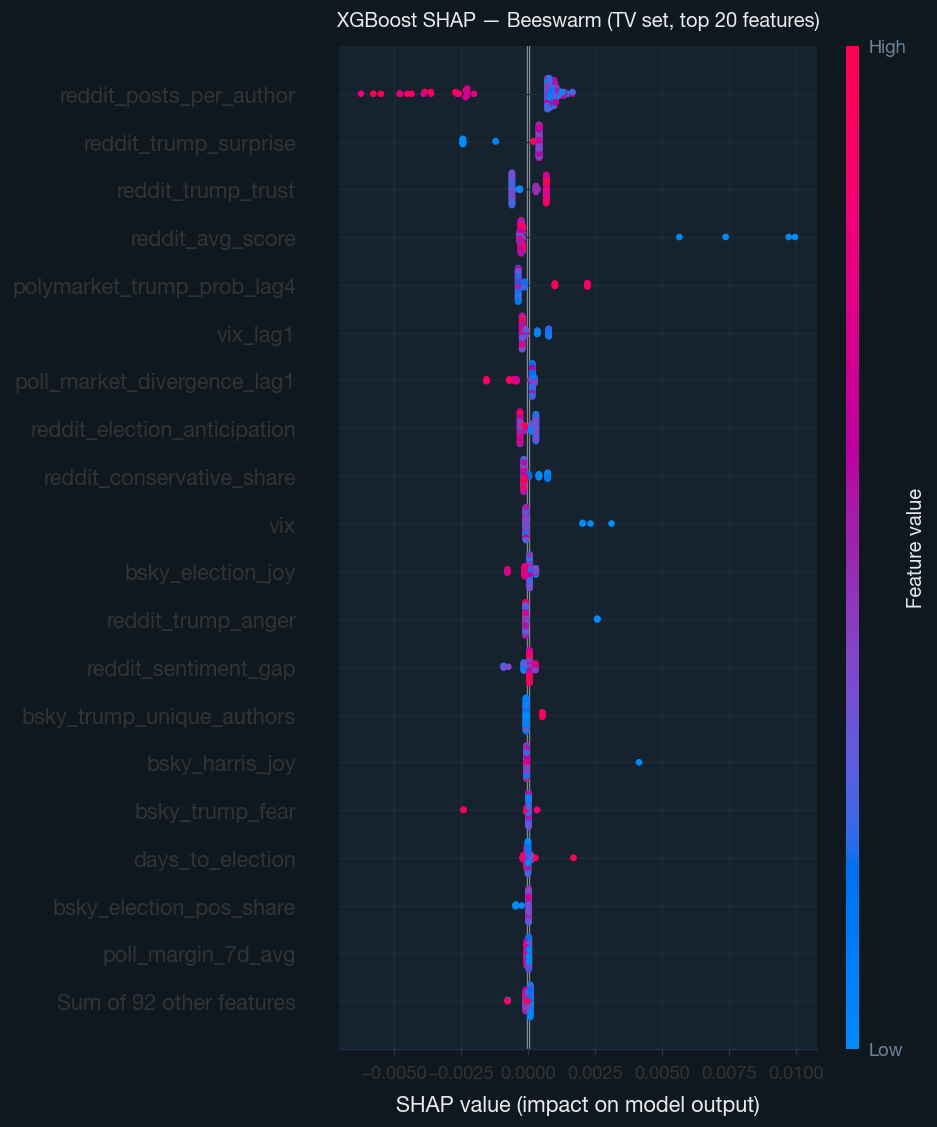

In [26]:
# ── Beeswarm summary plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
plt.gcf().patch.set_facecolor(BG_DARK)
shap.plots.beeswarm(shap_xgb_tv, max_display=20, show=False,
                    color_bar_label='Feature value')
plt.title('XGBoost SHAP — Beeswarm (TV set, top 20 features)',
          color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**How to read the beeswarm:**  
- Each **dot = one training day**; each **row = one feature** (ranked by mean |SHAP|, most important at top)  
- **X-axis (SHAP value):** how much this feature shifted the prediction for that day — right = pushed Trump prob up, left = pushed it down  
- **Colour:** the actual feature value for that dot (red = high, blue = low); this reveals *direction* of effect  
  - E.g. if red dots are on the right → *high values of this feature predict an upward move in Trump's probability*  
- Features clustered near 0 have little effect most days but may matter on specific days (outlier dots far from 0)

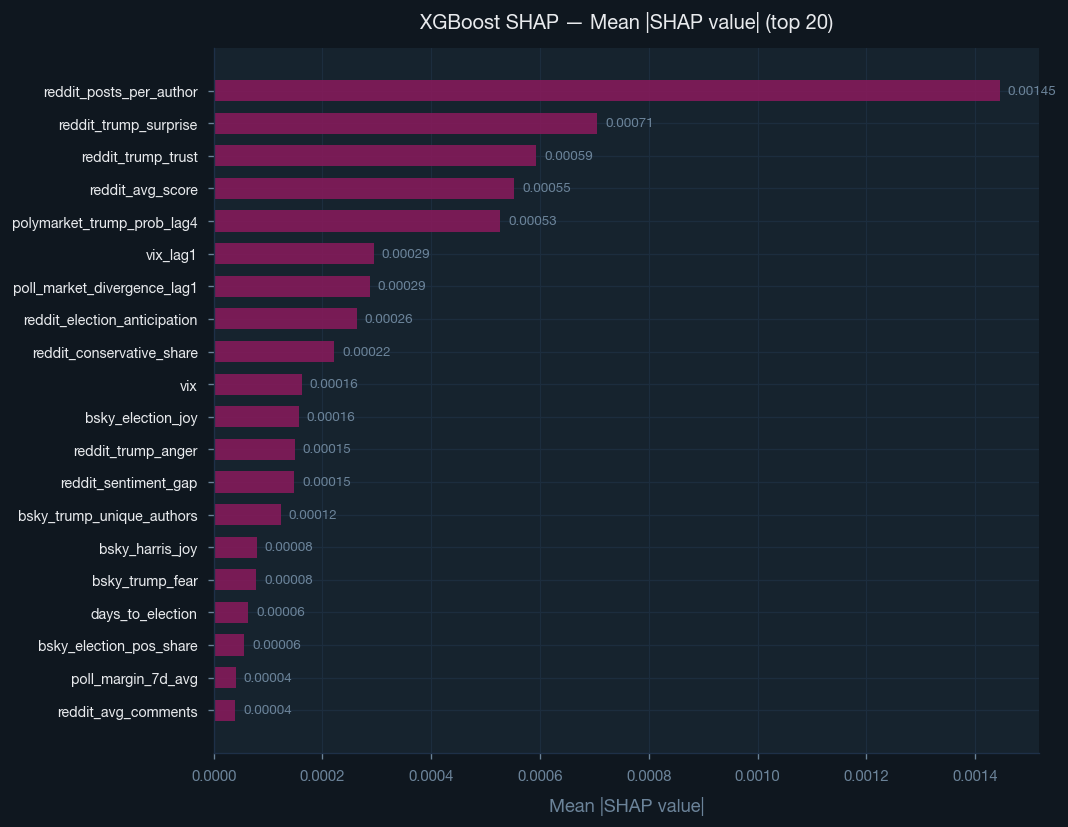

In [27]:
# ── Bar chart — mean |SHAP| ───────────────────────────────────────────────────
mean_abs_shap_xgb = pd.Series(
    np.abs(shap_xgb_tv.values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

top20 = mean_abs_shap_xgb.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(top20.index, top20.values,
               color=MODEL_COLORS['XGBoost'], alpha=0.85, height=0.65)
for bar, v in zip(bars, top20.values):
    ax.text(bar.get_width() + top20.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.5f}', va='center', ha='left', fontsize=8, color=TEXT_MUTED)
ax.set_title('XGBoost SHAP — Mean |SHAP value| (top 20)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|', color=TEXT_MUTED)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(top20.index, color=TEXT_PRIMARY, fontsize=8.5)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**How to read the bar chart:**  
Mean |SHAP| collapses the beeswarm to a single number per feature — it is the **average absolute impact** across all training days. Unlike the beeswarm, direction (sign) is lost here. Use this chart to rank features by *overall influence* and to compare quickly with the RF/XGBoost gain plots above. Features that appear both here *and* in the gain chart are doubly robust signal carriers.

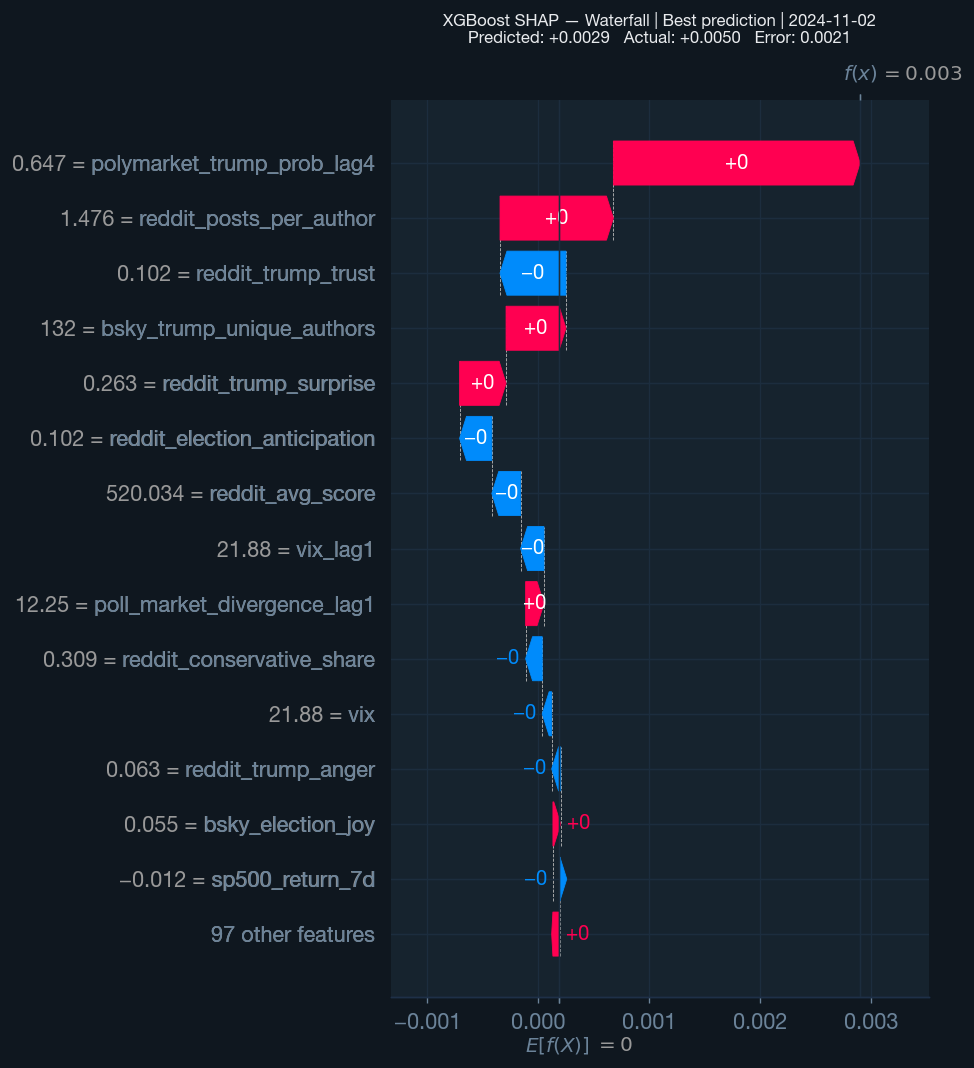

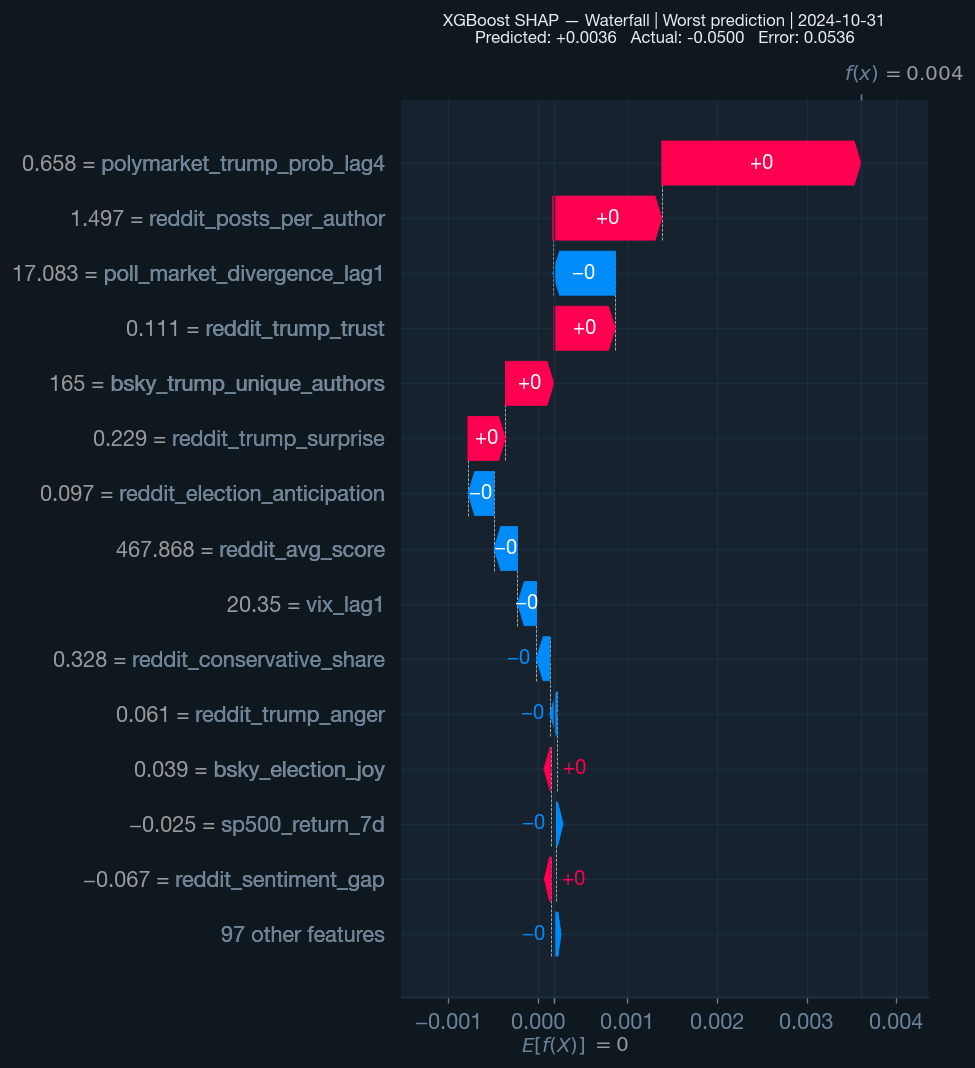

In [28]:
# ── Waterfall plots — best & worst test-set predictions ───────────────────────
errors   = np.abs(xgb_pred - y_test)
best_idx = int(np.argmin(errors))    # smallest error
worst_idx = int(np.argmax(errors))   # largest error

for idx, label in [(best_idx, 'Best prediction'), (worst_idx, 'Worst prediction')]:
    date_str = df_test['date'].iloc[idx].strftime('%Y-%m-%d')
    pred_v   = xgb_pred[idx]
    true_v   = y_test[idx]
    plt.figure(figsize=(10, 6))
    plt.gcf().patch.set_facecolor(BG_DARK)
    shap.plots.waterfall(shap_xgb_test[idx], max_display=15, show=False)
    plt.title(
        f'XGBoost SHAP — Waterfall | {label} | {date_str}\n'
        f'Predicted: {pred_v:+.4f}   Actual: {true_v:+.4f}   Error: {errors[idx]:.4f}',
        color=TEXT_PRIMARY, fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

**How to read the waterfall:**  
The waterfall shows the full SHAP decomposition for **a single day** (best and worst test-set prediction).  
- **Bottom anchor (E[f(x)] ≈ 0):** the model's average prediction — the starting point  
- **Each bar:** one feature's contribution pushing the prediction up (red) or down (blue)  
- **Top value f(x):** the final prediction for that day = baseline + sum of all SHAP bars  
- The *best prediction* day has many features agreeing (bars mostly one colour); the *worst* day has conflicting signals or a single large unexpected driver  
- Because the baseline is ≈ 0, even small SHAP contributions can flip the predicted direction

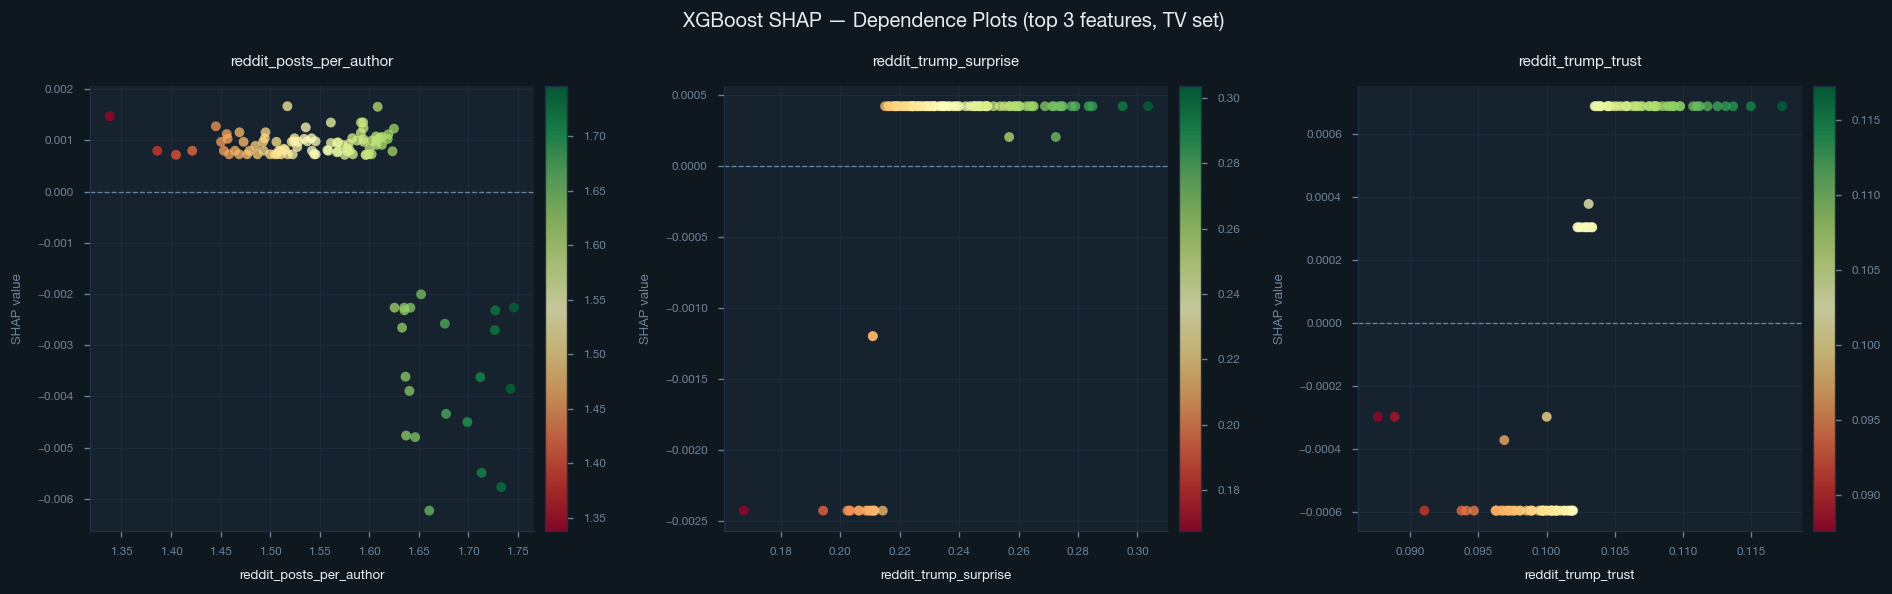

In [29]:
# ── Dependence plots — top 3 features ────────────────────────────────────────
top3 = mean_abs_shap_xgb.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('XGBoost SHAP — Dependence Plots (top 3 features, TV set)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')

for ax, feat in zip(axes, top3):
    feat_idx  = FEATURE_COLS.index(feat)
    feat_vals = X_tv[:, feat_idx]
    shap_vals = shap_xgb_tv.values[:, feat_idx]

    ax.set_facecolor(BG_PANEL)
    sc = ax.scatter(feat_vals, shap_vals,
                    c=feat_vals, cmap='RdYlGn', alpha=0.75, s=35,
                    edgecolors='none')
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')
    cb = plt.colorbar(sc, ax=ax, pad=0.02)
    cb.ax.tick_params(colors=TEXT_MUTED, labelsize=7)
    cb.outline.set_edgecolor(SPINE_COLOR)
    ax.set_xlabel(feat, color=TEXT_PRIMARY, fontsize=8)
    ax.set_ylabel('SHAP value', color=TEXT_MUTED, fontsize=8)
    ax.set_title(feat, color=TEXT_PRIMARY, fontsize=9, fontweight='bold')
    ax.tick_params(colors=TEXT_MUTED, labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.grid(color=GRID_COLOR, linewidth=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**How to read the dependence plots:**  
Each plot shows one feature's **non-linear relationship** with its SHAP value across all training days.  
- **X-axis:** raw feature value (from the data)  
- **Y-axis:** SHAP value for that feature on that day  
- **Colour:** same feature value (redundant here, but helps spot density)  
- **Dashed line at y=0:** SHAP=0 means the feature had no impact that day  
- A clear upward or downward slope → monotonic effect (feature consistently pushes in one direction as its value rises)  
- A non-linear pattern (e.g. U-shape, flat-then-steep) reveals threshold effects that linear models miss

## 4. SHAP — SVM KernelExplainer *(overall best model)*

The SVM is the best-performing model (DA=0.5714, MAE=0.0143) but has no tree structure — so `TreeExplainer` cannot be used. Instead, `KernelExplainer` estimates SHAP values by sampling.

### Why sampling?

An SVM is a black box: there is no tree to read. To compute Shapley values properly you would need to evaluate all 2¹¹¹ feature combinations — impossible. `KernelExplainer` instead:
1. Takes 50 background rows from the TV set
2. For each test day, randomly masks out groups of features (replacing them with values from background rows to simulate "this feature is absent")
3. Runs the SVM on each masked version and records how much the prediction changes
4. Fits a weighted linear model across all those samples to estimate each feature's contribution

**What "approximate" means in practice:** if you ran it again with a different random seed or more background rows, the numbers would shift slightly — but the *ranking* of which features matter most is stable. The 5th most important feature might actually be the 4th, but the top features and their direction are reliable. Raising `N_BACKGROUND` from 50 to e.g. 200 would make the estimates more stable, at the cost of more SVM evaluations.

> To increase accuracy: raise `N_BACKGROUND` to e.g. 100 or 200.

In [30]:
N_BACKGROUND = 100    # rows from TV set used to marginalise features
N_EXPLAIN    = len(X_test_s)   # test rows to explain

rng = np.random.default_rng(RANDOM_STATE)
bg_idx  = rng.choice(len(X_tv_s), size=N_BACKGROUND, replace=False)
X_bg    = X_tv_s[bg_idx]

print(f'Background sample : {N_BACKGROUND} rows')
print(f'Rows to explain   : {N_EXPLAIN}')
print('Running KernelExplainer...')

explainer_svm = shap.KernelExplainer(svm.predict, X_bg, feature_names=FEATURE_COLS)
shap_svm_test = explainer_svm.shap_values(X_test_s[:N_EXPLAIN], nsamples='auto', silent=True)

print(f'Done. SHAP values shape: {np.array(shap_svm_test).shape}')

Background sample : 100 rows
Rows to explain   : 14
Running KernelExplainer...
Done. SHAP values shape: (14, 111)


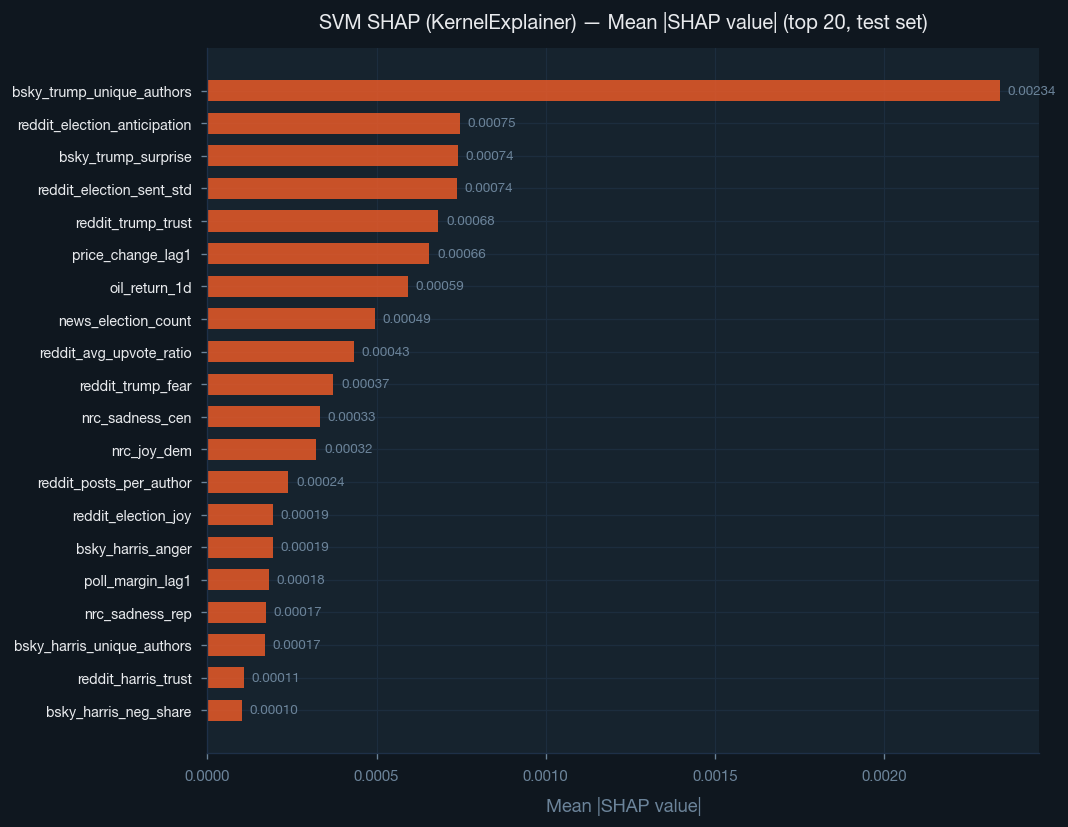

In [31]:
# ── Bar chart — mean |SHAP| ───────────────────────────────────────────────────
mean_abs_shap_svm = pd.Series(
    np.abs(np.array(shap_svm_test)).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

top20_svm = mean_abs_shap_svm.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(top20_svm.index, top20_svm.values,
               color=MODEL_COLORS['SVM'], alpha=0.85, height=0.65)
for bar, v in zip(bars, top20_svm.values):
    ax.text(bar.get_width() + top20_svm.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.5f}', va='center', ha='left', fontsize=8, color=TEXT_MUTED)
ax.set_title('SVM SHAP (KernelExplainer) — Mean |SHAP value| (top 20, test set)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|', color=TEXT_MUTED)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(top20_svm.index, color=TEXT_PRIMARY, fontsize=8.5)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

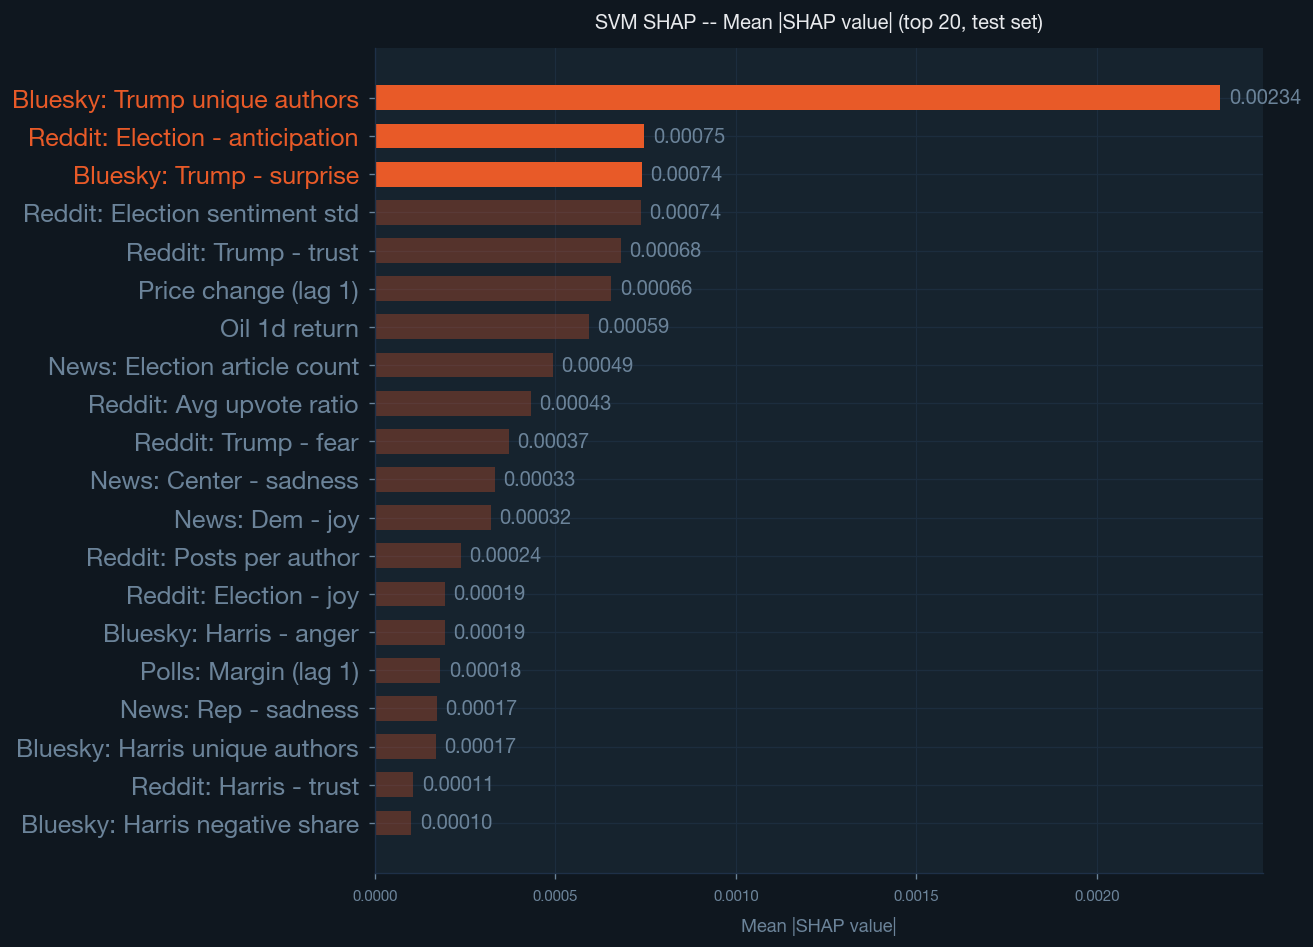

In [32]:
# SVM SHAP -- readable feature names
import json as _j
FEATURE_LABELS = _json.loads('{"days_to_election":"Days to election","bsky_trump_unique_authors":"Bluesky: Trump unique authors","bsky_harris_unique_authors":"Bluesky: Harris unique authors","bsky_trump_share":"Bluesky: Trump post share","bsky_harris_share":"Bluesky: Harris post share","bsky_posts_per_author":"Bluesky: Posts per author","bsky_trump_fear":"Bluesky: Trump - fear","bsky_trump_trust":"Bluesky: Trump - trust","bsky_trump_surprise":"Bluesky: Trump - surprise","bsky_trump_sadness":"Bluesky: Trump - sadness","bsky_trump_disgust":"Bluesky: Trump - disgust","bsky_trump_joy":"Bluesky: Trump - joy","bsky_harris_sent_avg":"Bluesky: Harris avg sentiment","bsky_harris_pos_share":"Bluesky: Harris positive share","bsky_harris_neg_share":"Bluesky: Harris negative share","bsky_harris_fear":"Bluesky: Harris - fear","bsky_harris_anger":"Bluesky: Harris - anger","bsky_harris_anticipation":"Bluesky: Harris - anticipation","bsky_harris_trust":"Bluesky: Harris - trust","bsky_harris_disgust":"Bluesky: Harris - disgust","bsky_harris_joy":"Bluesky: Harris - joy","bsky_election_sent_avg":"Bluesky: Election avg sentiment","bsky_election_sent_std":"Bluesky: Election sentiment std","bsky_election_pos_share":"Bluesky: Election positive share","bsky_election_neg_share":"Bluesky: Election negative share","bsky_election_surprise":"Bluesky: Election - surprise","bsky_election_joy":"Bluesky: Election - joy","bsky_sentiment_gap":"Bluesky: Trump-Harris sentiment gap","reddit_unique_authors":"Reddit: Unique authors","reddit_avg_score":"Reddit: Avg post score","reddit_avg_upvote_ratio":"Reddit: Avg upvote ratio","reddit_avg_comments":"Reddit: Avg comments","reddit_harris_unique_authors":"Reddit: Harris unique authors","reddit_harris_share":"Reddit: Harris post share","reddit_conservative_share":"Reddit: Conservative post share","reddit_posts_per_author":"Reddit: Posts per author","reddit_trump_sent_avg":"Reddit: Trump avg sentiment","reddit_trump_sent_std":"Reddit: Trump sentiment std","reddit_trump_fear":"Reddit: Trump - fear","reddit_trump_anger":"Reddit: Trump - anger","reddit_trump_anticipation":"Reddit: Trump - anticipation","reddit_trump_trust":"Reddit: Trump - trust","reddit_trump_surprise":"Reddit: Trump - surprise","reddit_trump_sadness":"Reddit: Trump - sadness","reddit_trump_disgust":"Reddit: Trump - disgust","reddit_trump_joy":"Reddit: Trump - joy","reddit_harris_sent_std":"Reddit: Harris sentiment std","reddit_harris_anticipation":"Reddit: Harris - anticipation","reddit_harris_trust":"Reddit: Harris - trust","reddit_harris_sadness":"Reddit: Harris - sadness","reddit_harris_disgust":"Reddit: Harris - disgust","reddit_harris_joy":"Reddit: Harris - joy","reddit_election_sent_std":"Reddit: Election sentiment std","reddit_election_fear":"Reddit: Election - fear","reddit_election_anger":"Reddit: Election - anger","reddit_election_anticipation":"Reddit: Election - anticipation","reddit_election_surprise":"Reddit: Election - surprise","reddit_election_sadness":"Reddit: Election - sadness","reddit_election_joy":"Reddit: Election - joy","reddit_sentiment_gap":"Reddit: Trump-Harris sentiment gap","news_election_count":"News: Election article count","news_attention_asymmetry_7d":"News: 7d attention asymmetry","vader_compound_mean_dem":"News: Dem outlet avg sentiment","vader_compound_std_dem":"News: Dem outlet sentiment std","vader_neg_share_dem":"News: Dem outlet negative share","nrc_fear_cen":"News: Center - fear","nrc_anger_cen":"News: Center - anger","nrc_anticipation_dem":"News: Dem - anticipation","nrc_anticipation_rep":"News: Rep - anticipation","nrc_anticipation_cen":"News: Center - anticipation","nrc_surprise_dem":"News: Dem - surprise","nrc_surprise_cen":"News: Center - surprise","nrc_sadness_dem":"News: Dem - sadness","nrc_sadness_rep":"News: Rep - sadness","nrc_sadness_cen":"News: Center - sadness","nrc_disgust_dem":"News: Dem - disgust","nrc_joy_dem":"News: Dem - joy","nrc_joy_cen":"News: Center - joy","news_vader_leaning_gap":"News: Dem-Rep sentiment gap","gt_trump":"Google Trends: Trump","gt_kamala":"Google Trends: Kamala","gt_walz":"Google Trends: Walz","gt_election_2024":"Google Trends: Election 2024","gt_trump_minus_kamala":"Google Trends: Trump minus Kamala","gt_trump_share":"Google Trends: Trump share","gt_trump_7d":"Google Trends: Trump 7d avg","gt_kamala_7d":"Google Trends: Kamala 7d avg","poll_trump_avg":"Polls: Trump average","poll_harris_avg":"Polls: Harris average","poll_margin":"Polls: Trump-Harris margin","poll_trump_7d_avg":"Polls: Trump 7d avg","poll_harris_7d_avg":"Polls: Harris 7d avg","poll_margin_7d_avg":"Polls: Margin 7d avg","poll_volatility_7d":"Polls: 7d volatility","oil":"Oil price","vix":"VIX (market fear)","bond_10y":"10y bond yield","usd_index":"USD index","sp500_return_7d":"SP500 7d return","sp500_vol_7d":"SP500 7d volatility","oil_return_1d":"Oil 1d return","vix_change_1d":"VIX 1d change","polymarket_trump_prob_lag4":"Polymarket Trump prob (lag 4)","price_change_lag1":"Price change (lag 1)","bsky_sentiment_gap_lag1":"Bluesky: Sentiment gap (lag 1)","poll_margin_lag1":"Polls: Margin (lag 1)","poll_market_divergence_lag1":"Poll-market divergence (lag 1)","gt_trump_lag1":"Google Trends: Trump (lag 1)","gt_trump_share_lag1":"Google Trends: Trump share (lag 1)","vix_lag1":"VIX (lag 1)","reddit_sentiment_gap_lag1":"Reddit: Sentiment gap (lag 1)"}')

top20_svm_named = mean_abs_shap_svm.head(20).copy()
top20_svm_named.index = [FEATURE_LABELS.get(i, i) for i in top20_svm_named.index]
top20_svm_named = top20_svm_named.iloc[::-1]
ORANGE      = '#e85a28'
ORANGE_SOFT = (0.91, 0.35, 0.16, 0.3)
n = len(top20_svm_named)
bar_colors   = [ORANGE if i >= n-3 else ORANGE_SOFT for i in range(n)]
label_colors = [ORANGE if i >= n-3 else "#6b8399" for i in range(n)]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(top20_svm_named.index, top20_svm_named.values,
               color=bar_colors, height=0.65)
for bar, v in zip(bars, top20_svm_named.values):
    ax.text(bar.get_width() + top20_svm_named.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.5f}', va='center', ha='left', fontsize=12, color=TEXT_MUTED)
ax.set_title('SVM SHAP -- Mean |SHAP value| (top 20, test set)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|', color=TEXT_MUTED)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticks(range(n))
ax.set_yticklabels(top20_svm_named.index, fontsize=15)
for tick, clr in zip(ax.get_yticklabels(), label_colors):
    tick.set_color(clr)
    tick.set_fontweight('bold' if clr == ORANGE else 'normal')
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


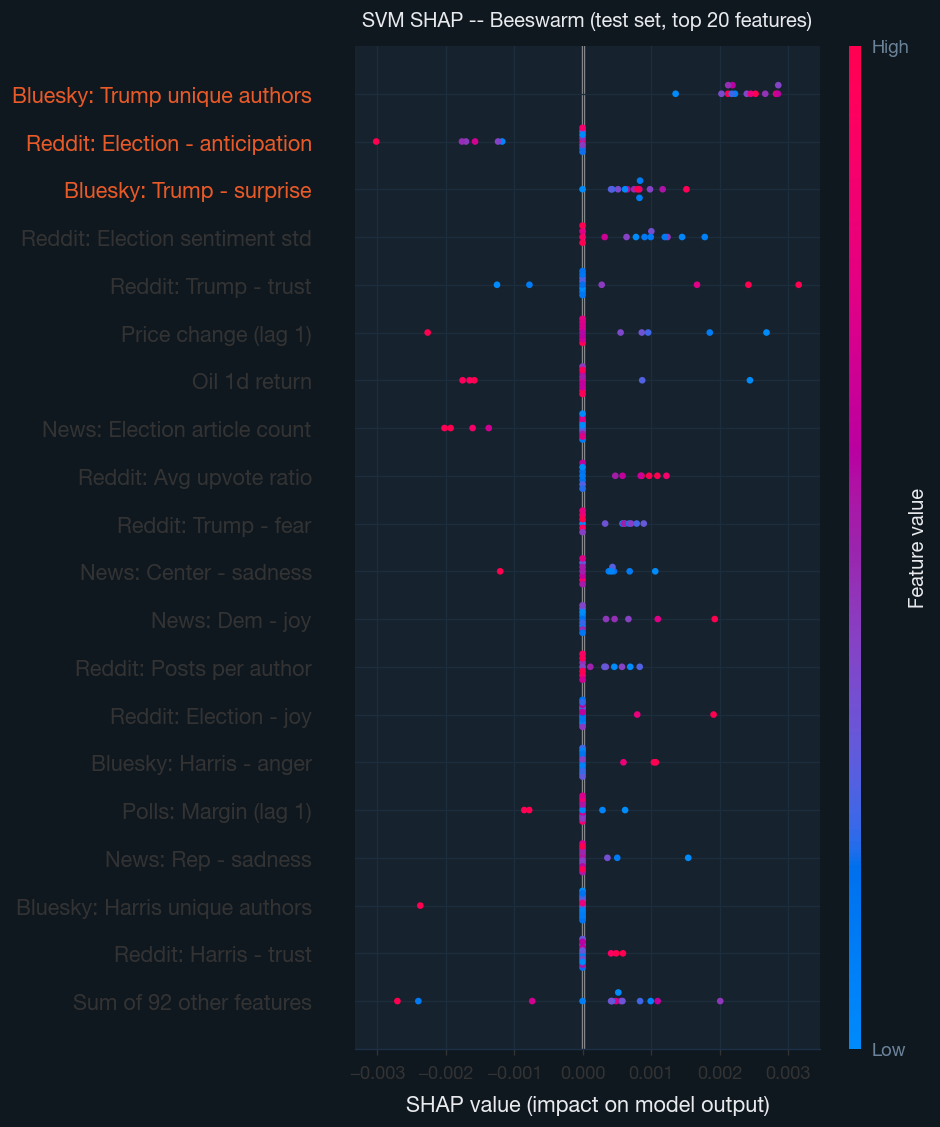

In [33]:
# SVM SHAP beeswarm -- readable feature names
ORANGE = '#e85a28'
shap_svm_exp_named = shap.Explanation(
    values       = np.array(shap_svm_test),
    base_values  = explainer_svm.expected_value,
    data         = X_test_s[:N_EXPLAIN],
    feature_names= [FEATURE_LABELS.get(c, c) for c in FEATURE_COLS],
)
plt.figure(figsize=(10, 8))
plt.gcf().patch.set_facecolor(BG_DARK)
shap.plots.beeswarm(shap_svm_exp_named, max_display=20, show=False,
                    color_bar_label='Feature value')
plt.title('SVM SHAP -- Beeswarm (test set, top 20 features)',
          color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax_bee = plt.gca()
ticks = ax_bee.get_yticklabels()
for i, tick in enumerate(ticks):
    if i >= len(ticks) - 3:
        tick.set_color(ORANGE)
        tick.set_fontweight('bold')
plt.tight_layout()
plt.show()


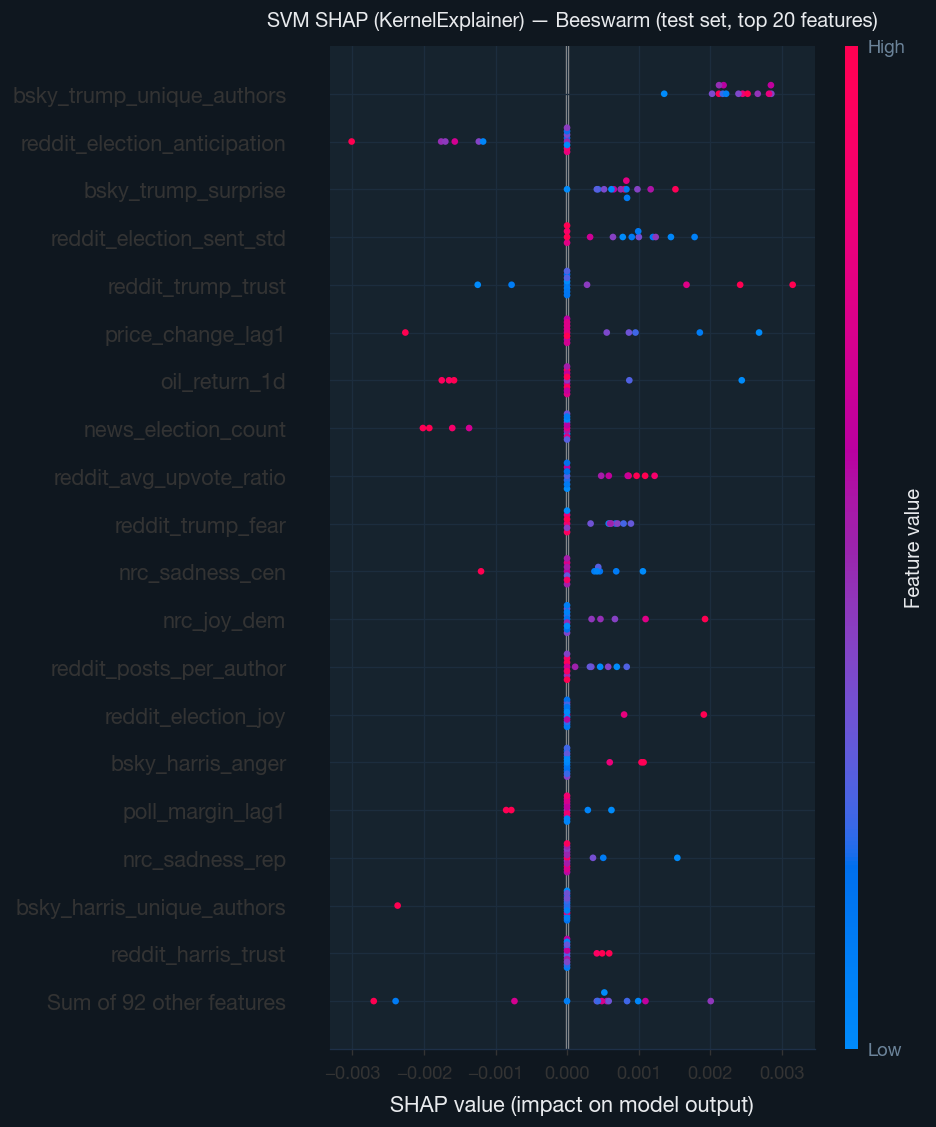

In [34]:
# ── Beeswarm summary ─────────────────────────────────────────────────────────
shap_svm_exp = shap.Explanation(
    values          = np.array(shap_svm_test),
    base_values     = explainer_svm.expected_value,
    data            = X_test_s[:N_EXPLAIN],
    feature_names   = FEATURE_COLS,
)
plt.figure(figsize=(10, 8))
plt.gcf().patch.set_facecolor(BG_DARK)
shap.plots.beeswarm(shap_svm_exp, max_display=20, show=False,
                    color_bar_label='Feature value')
plt.title('SVM SHAP (KernelExplainer) — Beeswarm (test set, top 20 features)',
          color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Cross-model SHAP comparison — SVM vs XGBoost

Side-by-side bar chart of mean |SHAP| rankings for the **union of top-15 features** from each model.

**How to read:**  
- Features where **both bars are long** → robustly important regardless of model class. These are the strongest candidates for substantive interpretation.  
- Features where **only SVM bar is long** → important for the RBF kernel's non-linear separating surface but not captured by shallow trees  
- Features where **only XGBoost bar is long** → tree-specific splits, possibly noisy or tied to a specific threshold  
- The **Spearman rank correlation** printed below quantifies overall agreement: ρ close to 1 = both models rank features similarly (reassuring); ρ close to 0 = models rely on fundamentally different signals

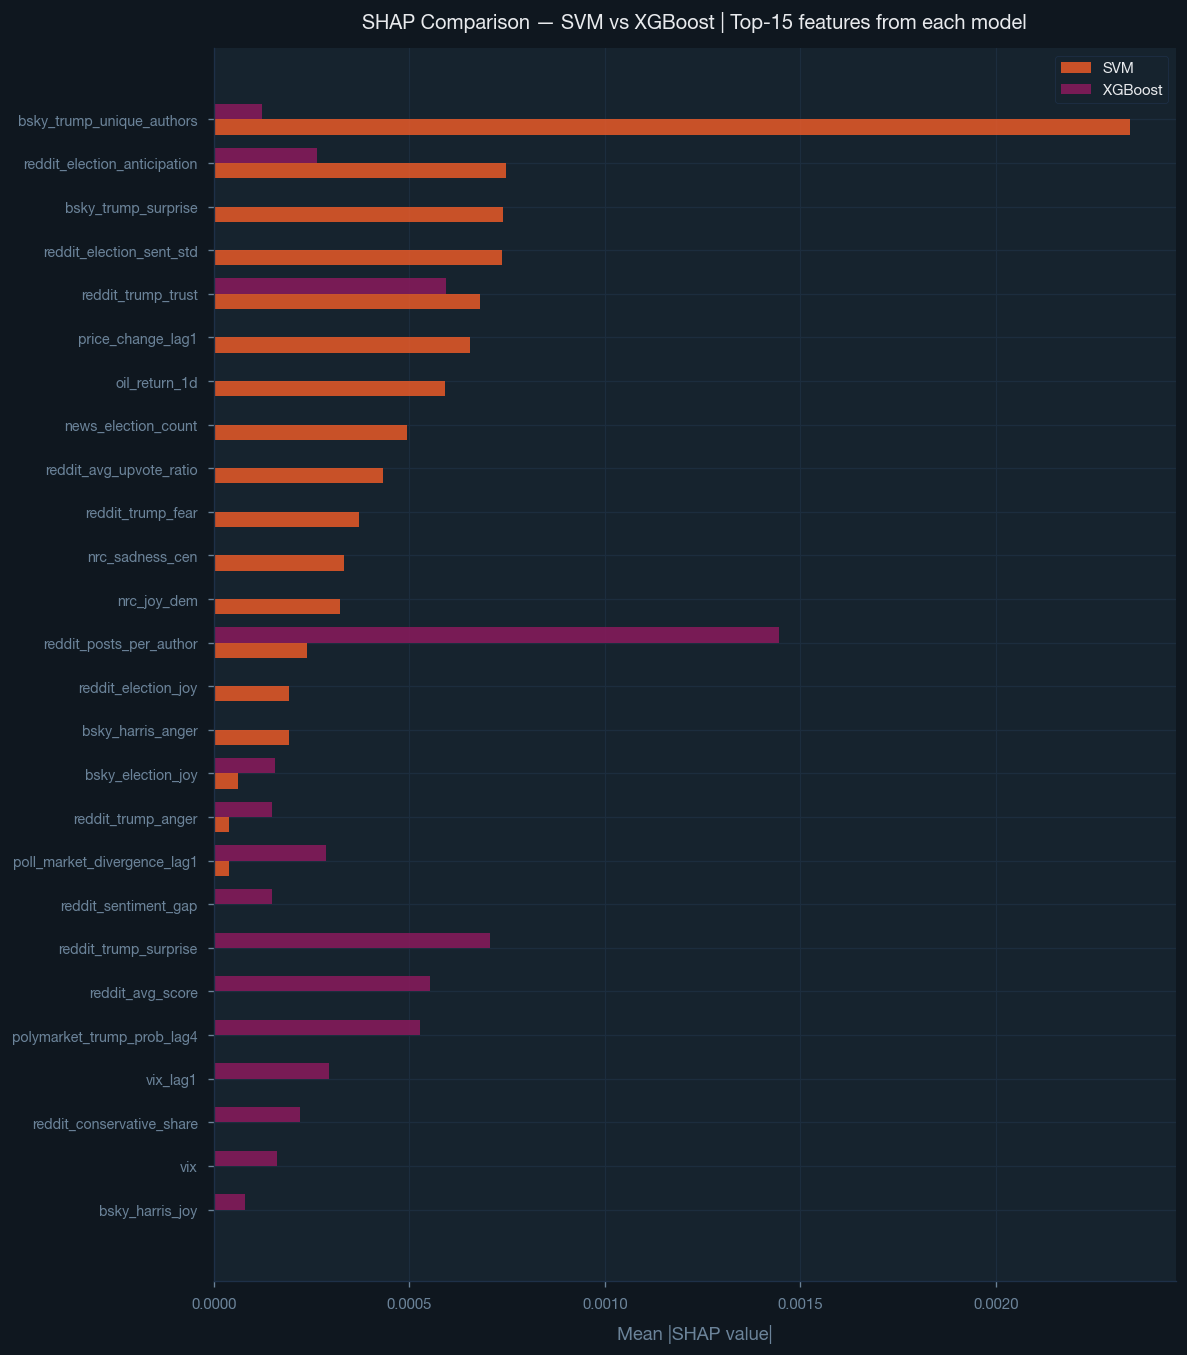

Spearman rank correlation (SVM vs XGBoost feature importance): ρ = 0.034  (p = 0.727)


In [35]:
N_TOP = 15

# Union of top-N features from each model
top_union = pd.Index(
    mean_abs_shap_svm.head(N_TOP).index.tolist() +
    mean_abs_shap_xgb.head(N_TOP).index.tolist()
).unique()

compare_df = pd.DataFrame({
    'SVM'    : mean_abs_shap_svm.reindex(top_union, fill_value=0),
    'XGBoost': mean_abs_shap_xgb.reindex(top_union, fill_value=0),
}).sort_values('SVM', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(compare_df) * 0.4 + 1)))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

y      = np.arange(len(compare_df))
height = 0.35

ax.barh(y - height/2, compare_df['SVM'].values,
        height=height, color=MODEL_COLORS['SVM'],    alpha=0.85, label='SVM')
ax.barh(y + height/2, compare_df['XGBoost'].values,
        height=height, color=MODEL_COLORS['XGBoost'], alpha=0.85, label='XGBoost')

ax.set_yticks(y)
ax.set_yticklabels(compare_df.index, color=TEXT_PRIMARY, fontsize=8.5)
ax.set_xlabel('Mean |SHAP value|', color=TEXT_MUTED)
ax.set_title(
    f'SHAP Comparison — SVM vs XGBoost | Top-{N_TOP} features from each model',
    color=TEXT_PRIMARY, fontsize=12, fontweight='bold'
)
ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9)
ax.tick_params(colors=TEXT_MUTED)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Rank correlation between the two models ───────────────────────────────────
from scipy.stats import spearmanr
all_feats = mean_abs_shap_svm.index  # same feature set
r, p = spearmanr(
    mean_abs_shap_svm.reindex(all_feats).values,
    mean_abs_shap_xgb.reindex(all_feats).values
)
print(f'Spearman rank correlation (SVM vs XGBoost feature importance): ρ = {r:.3f}  (p = {p:.3f})')

## 6. Ridge Regression — Standardised Coefficients

Ridge coefficients on standardised (z-scored) features are directly interpretable as linear importance scores — they are essentially a linear version of SHAP.

**How to read:**  
- **Sign tells you direction:** a positive coefficient means "when this feature is above average, Trump's probability tends to go up that day"; negative means "above-average value of this feature is associated with a downward move"  
- **Magnitude tells you relative importance:** because features are standardised, a coefficient of +0.01 means a 1 SD increase in that feature is associated with a +0.01 pp change in Trump's daily probability  
- **Heavy regularisation (α=1000)** shrinks all coefficients strongly toward zero — only features with consistent, strong linear signal survive with non-negligible coefficients  
- Compare with the SHAP plots: features with large Ridge coefficients *and* large SHAP values (both models) are the most trustworthy signals in the data

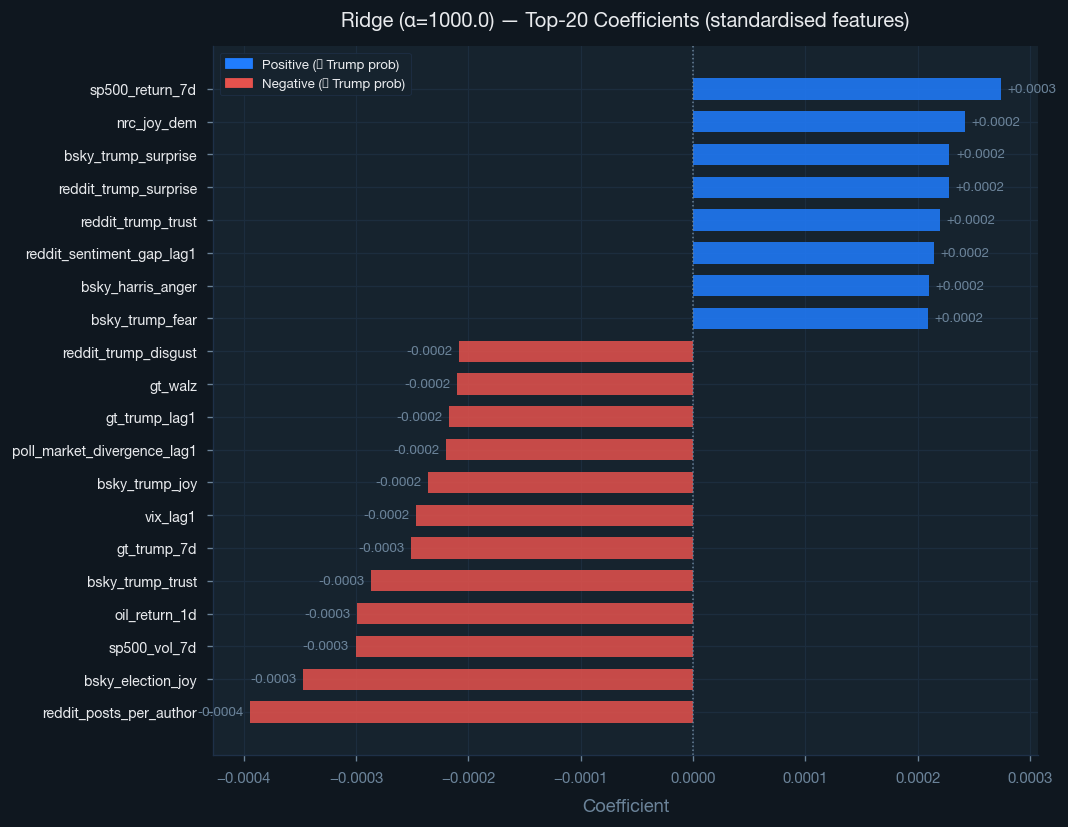

In [36]:
coefs = pd.Series(ridge.coef_, index=FEATURE_COLS).sort_values(key=abs, ascending=False)
top20_coef = coefs.head(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
colors = [MODEL_COLORS['Ridge'] if v >= 0 else REPUBLICAN for v in top20_coef.values]
bars = ax.barh(top20_coef.index, top20_coef.values, color=colors, alpha=0.85, height=0.65)
ax.axvline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=':')
for bar, v in zip(bars, top20_coef.values):
    offset = top20_coef.abs().max() * 0.015
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + (offset if v >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f'{v:+.4f}', va='center', ha=ha, fontsize=8, color=TEXT_MUTED)
ax.set_title(f'Ridge (α={RIDGE_ALPHA}) — Top-20 Coefficients (standardised features)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient', color=TEXT_MUTED)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(top20_coef.index, color=TEXT_PRIMARY, fontsize=8.5)
pos_patch = mpatches.Patch(color=MODEL_COLORS['Ridge'], label='Positive (↑ Trump prob)')
neg_patch = mpatches.Patch(color=REPUBLICAN,            label='Negative (↓ Trump prob)')
ax.legend(handles=[pos_patch, neg_patch],
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. Predictions vs Actuals — Test Period (Oct 22 – Nov 4)

All four models on the 14 held-out test days. This makes DA and MAE concrete: you can see exactly which days each model got the direction right and how large the errors were.

The test window covers the last two weeks before election day (Nov 5) — arguably the most volatile and uncertain period of the campaign, when prediction markets were moving on every new poll, debate reaction, and news event.

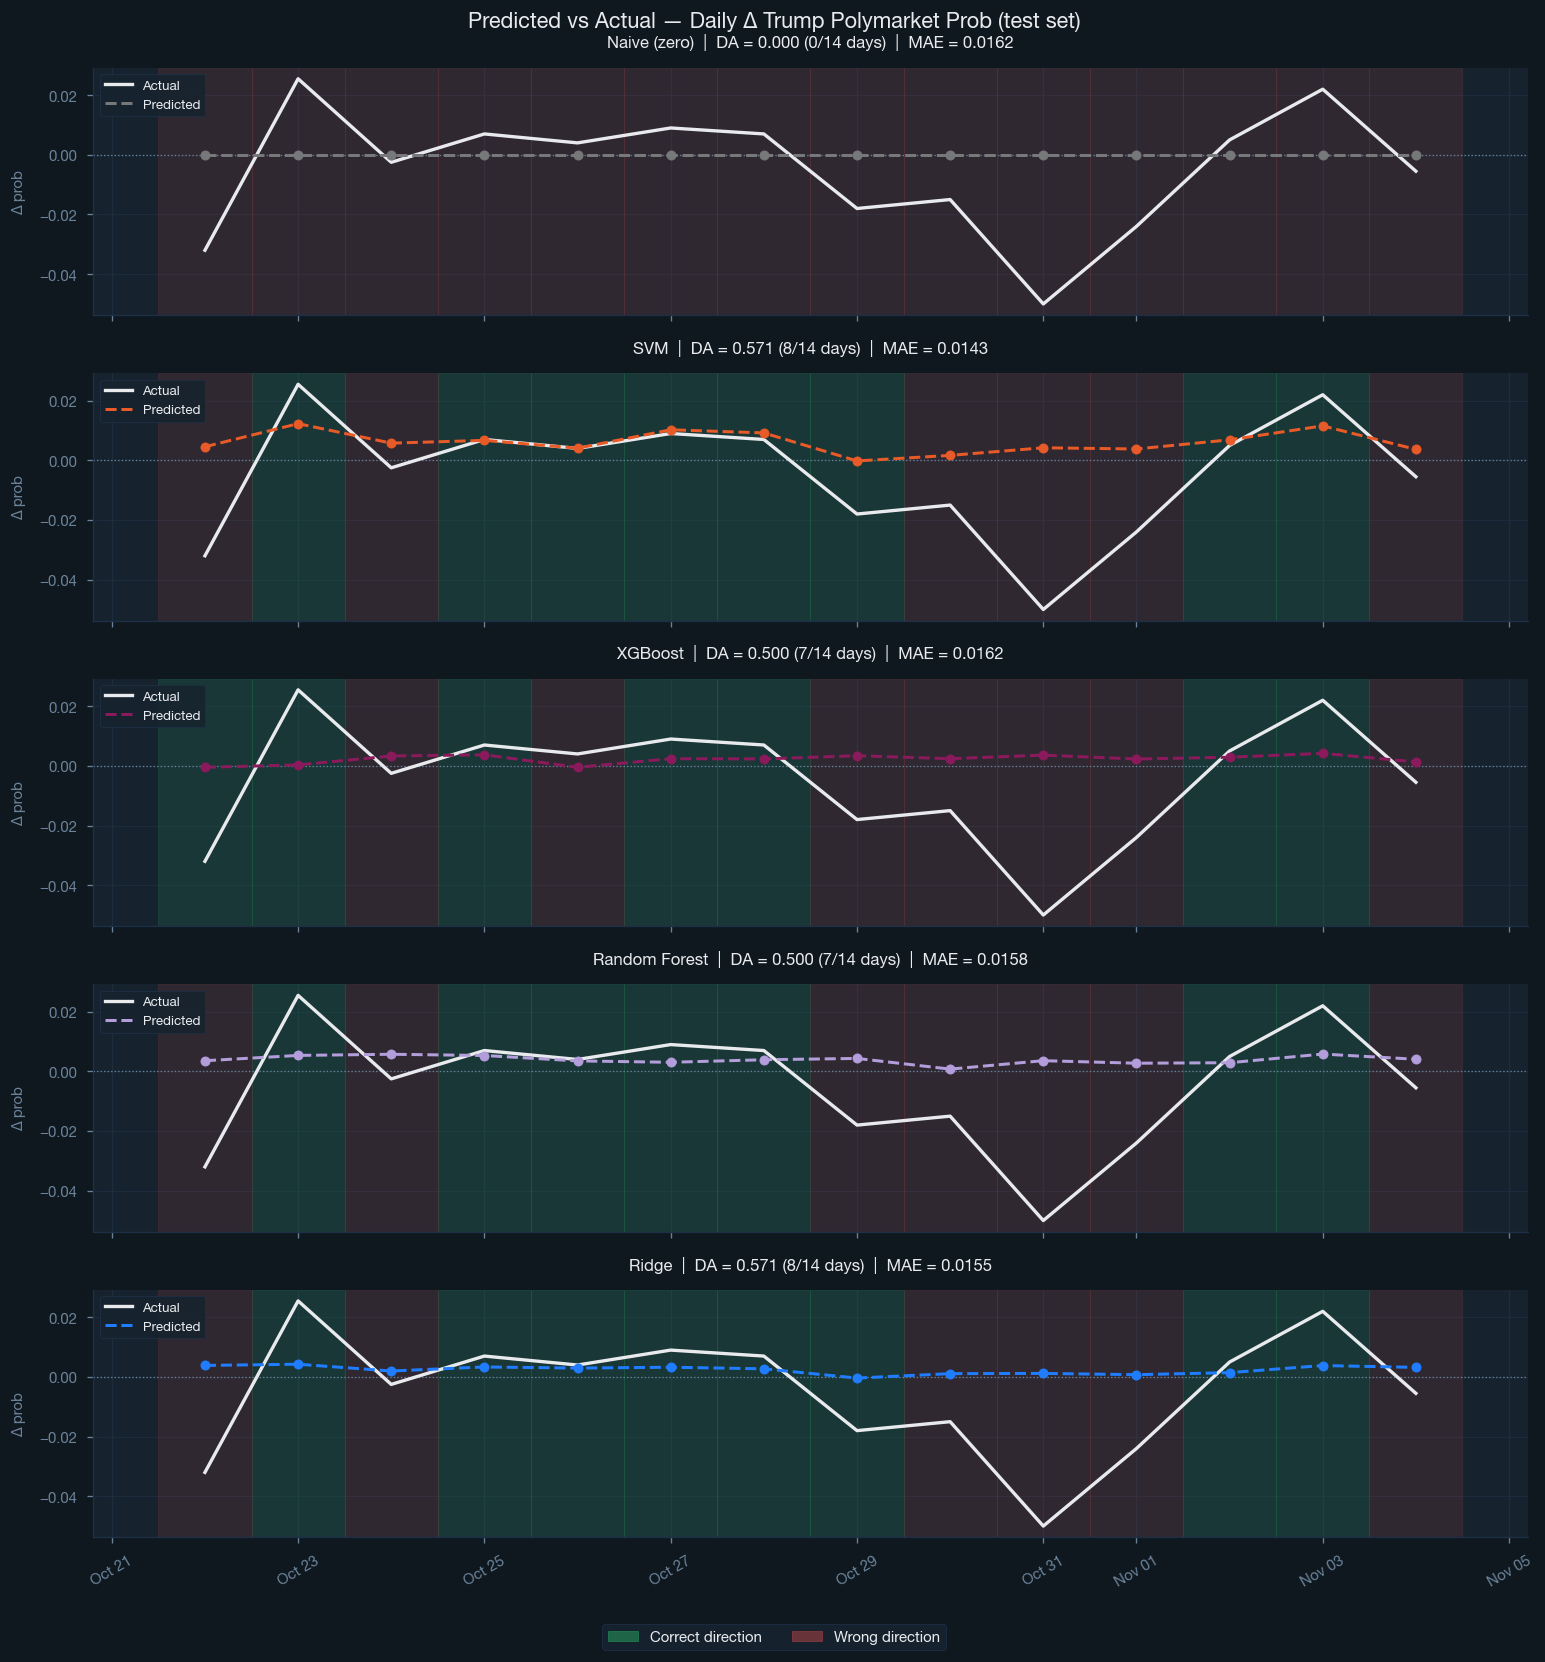

In [37]:

test_dates = pd.to_datetime(df_test['date'])

preds = {
    'Naive (zero)' : naive_pred,
    'SVM'          : svm_pred,
    'XGBoost'      : xgb_pred,
    'Random Forest': rf_pred,
    'Ridge'        : ridge_pred,
}

NAIVE_COLOR = NEUTRAL

fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Predicted vs Actual — Daily Δ Trump Polymarket Prob (test set)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')

for ax, (label, pred) in zip(axes, preds.items()):
    ax.set_facecolor(BG_PANEL)
    color = NAIVE_COLOR if label == 'Naive (zero)' else MODEL_COLORS[label]

    # shade correct/wrong direction
    for d, p, a in zip(test_dates, pred, y_test):
        correct = (np.sign(p) == np.sign(a)) and (a != 0)
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
                   color='#2ecc71' if correct else REPUBLICAN, alpha=0.12)

    ax.plot(test_dates, y_test, color=TEXT_PRIMARY, linewidth=2, label='Actual', zorder=3)
    ax.plot(test_dates, pred, color=color, linewidth=1.8, linestyle='--',
            label='Predicted', zorder=3)
    ax.scatter(test_dates, pred, color=color, s=30, zorder=4)
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle=':')

    da  = directional_accuracy(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    n_correct = int(round(da * len(y_test)))
    ax.set_title(
        f'{label}  |  DA = {da:.3f} ({n_correct}/{len(y_test)} days)  |  MAE = {mae:.4f}',
        color=TEXT_PRIMARY, fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Δ prob', color=TEXT_MUTED, fontsize=9)
    ax.tick_params(colors=TEXT_MUTED)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.5)
    ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
              fontsize=8, loc='upper left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].tick_params(axis='x', rotation=30, colors=TEXT_MUTED)

fig.legend(
    handles=[mpatches.Patch(color='#2ecc71', alpha=0.4, label='Correct direction'),
             mpatches.Patch(color=REPUBLICAN, alpha=0.4, label='Wrong direction')],
    loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2,
    facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 8. Limitations & Honest Takeaways

### What the numbers actually mean
- **DA = 0.5714 = 8/14 days correct.** A coin flip would get 7. The margin is real but thin — one extra correct day separates our best model from chance.
- **R² < 0 for all models.** Predicting daily changes in an efficient prediction market is fundamentally hard. The market already incorporates most available information, so any remaining signal is weak.

### The model disagreement problem (ρ = 0.034)
The Spearman correlation between SVM and XGBoost feature importances is essentially zero. Two models with similar test performance rely on completely different features — SVM leans on Bluesky engagement metrics, XGBoost on Reddit posting patterns. When two models agree on *what* to use, you can trust the interpretation. When they disagree this much, both are likely finding different noise patterns rather than a shared true signal.

### The test window caveat
The test set is Oct 22 – Nov 4: the two weeks immediately before election day, when markets were at their tightest and most reactive. This is the hardest possible period to predict — small news items caused large swings. CV performance (July–October) was run on a calmer, more predictable phase of the campaign. Treat the test numbers with that context in mind.
